# PBS Multi Measure

여러 PBS CSV에서 시간별 Vth를 계산하고, 각 데이터의 Delta Vth vs time을 한 그래프에 겹쳐 그립니다.

In [20]:
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from IPython.display import display

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid'] = True


In [21]:
# CSV path 입력
# path1~3 : Vg=1.0V, Vd=0V
# path4~6 : Vg=1.0V, Vd=1V
# path7~9 : Vg=1.0V, Vd=2V

path1 = "PBTI_IGZO_new2 [260331_WF02_#4_UPPER_UNITTR_PBS_VG1V_VD0V_R0(1) ; 4_15_2026 9_22_52 AM].csv"
path2 = "PBTI_IGZO_new2 [260331_WF02_#4_UPPER_UNITTR_PBS_VG1V_VD0V_R1(2) ; 4_15_2026 10_09_07 AM].csv"
path3 = "PBTI_IGZO_new2 [260331_WF02_#4_UPPER_UNITTR_PBS_VG1V_VD0V_R2(3) ; 4_15_2026 11_01_47 AM].csv"

path4 = "PBTI_IGZO_new2 [260331_WF02_#4_UPPER_UNITTR_PBS_VG1V_VD1V_R3(4) ; 4_15_2026 11_38_37 AM].csv"
path5 = "PBTI_IGZO_new2 [260331_WF02_#4_UPPER_UNITTR_PBS_VG1V_VD1V_R4(5) ; 4_15_2026 12_57_00 PM].csv"
path6 = "PBTI_IGZO_new2 [260331_WF02_#4_UPPER_UNITTR_PBS_VG1V_VD1V_R5(6) ; 4_15_2026 2_08_17 PM].csv"

path7 = "PBTI_IGZO_new2 [260331_WF02_#4_UPPER_UNITTR_PBS_VG1V_VD2V_R6(7) ; 4_15_2026 4_14_53 PM].csv"
path8 = "PBTI_IGZO_new2 [260331_WF02_#4_UPPER_UNITTR_PBS_VG1V_VD2V_R7(8) ; 4_15_2026 4_57_58 PM].csv"
path9 = "PBTI_IGZO_new2 [260331_WF02_#4_UPPER_UNITTR_PBS_VG1V_VD2V_R8(9) ; 4_15_2026 5_34_47 PM].csv"

dataset_infos = [
    {"path": path1, "vg": 1.0, "vd": 0, "data_idx": 1},
    {"path": path2, "vg": 1.0, "vd": 0, "data_idx": 2},
    {"path": path3, "vg": 1.0, "vd": 0, "data_idx": 3},
    {"path": path4, "vg": 1.0, "vd": 1, "data_idx": 1},
    {"path": path5, "vg": 1.0, "vd": 1, "data_idx": 2},
    {"path": path6, "vg": 1.0, "vd": 1, "data_idx": 3},
    {"path": path7, "vg": 1.0, "vd": 2, "data_idx": 1},
    {"path": path8, "vg": 1.0, "vd": 2, "data_idx": 2},
    {"path": path9, "vg": 1.0, "vd": 2, "data_idx": 3},
]

for info in dataset_infos:
    info["label"] = f"Vg={info['vg']}[V], Vd={info['vd']}[V] data{info['data_idx']}"

dataset_infos


[{'path': 'PBTI_IGZO_new2 [260331_WF02_#4_UPPER_UNITTR_PBS_VG1V_VD0V_R0(1) ; 4_15_2026 9_22_52 AM].csv',
  'vg': 1.0,
  'vd': 0,
  'data_idx': 1,
  'label': 'Vg=1.0[V], Vd=0[V] data1'},
 {'path': 'PBTI_IGZO_new2 [260331_WF02_#4_UPPER_UNITTR_PBS_VG1V_VD0V_R1(2) ; 4_15_2026 10_09_07 AM].csv',
  'vg': 1.0,
  'vd': 0,
  'data_idx': 2,
  'label': 'Vg=1.0[V], Vd=0[V] data2'},
 {'path': 'PBTI_IGZO_new2 [260331_WF02_#4_UPPER_UNITTR_PBS_VG1V_VD0V_R2(3) ; 4_15_2026 11_01_47 AM].csv',
  'vg': 1.0,
  'vd': 0,
  'data_idx': 3,
  'label': 'Vg=1.0[V], Vd=0[V] data3'},
 {'path': 'PBTI_IGZO_new2 [260331_WF02_#4_UPPER_UNITTR_PBS_VG1V_VD1V_R3(4) ; 4_15_2026 11_38_37 AM].csv',
  'vg': 1.0,
  'vd': 1,
  'data_idx': 1,
  'label': 'Vg=1.0[V], Vd=1[V] data1'},
 {'path': 'PBTI_IGZO_new2 [260331_WF02_#4_UPPER_UNITTR_PBS_VG1V_VD1V_R4(5) ; 4_15_2026 12_57_00 PM].csv',
  'vg': 1.0,
  'vd': 1,
  'data_idx': 2,
  'label': 'Vg=1.0[V], Vd=1[V] data2'},
 {'path': 'PBTI_IGZO_new2 [260331_WF02_#4_UPPER_UNITTR_PBS_VG1V_VD

In [22]:
def load_pbs_csv(path):
    rows = []
    with open(path, "r", encoding="utf-8-sig", errors="replace", newline="") as f:
        reader = csv.reader(f)
        for row in reader:
            rows.append(row)

    max_len = max(len(row) for row in rows)
    rows = [row + [""] * (max_len - len(row)) for row in rows]
    raw_data = pd.DataFrame(rows)

    is_datavalue = raw_data[0].isin(["DataValue"])
    raw_data = raw_data[is_datavalue].copy()
    raw_data = raw_data.iloc[:, 1:6]
    raw_data.columns = ["Vgate", "Vdrain", "Idrain", "IdMax", "Vth@Id"]

    df = raw_data.copy()
    time_series = df.loc[df["Idrain"].isin([" "]), "Vgate"]
    time_list = list(reversed(time_series.tolist()))
    time_count = len(time_list)
    df = df.iloc[time_count:, :].copy()

    df["IdMax"] = pd.to_numeric(df["IdMax"], errors="coerce")
    df["block"] = df["IdMax"].notna().cumsum()
    df = df[df["block"] > 0].copy()

    mapping = {i + 1: t for i, t in enumerate(time_list)}
    df["time_s"] = df["block"].map(mapping)

    df["Vgate"] = pd.to_numeric(df["Vgate"], errors="coerce")
    df["Vdrain"] = pd.to_numeric(df["Vdrain"], errors="coerce")
    df["Idrain"] = pd.to_numeric(df["Idrain"], errors="coerce").abs()
    df["time_s"] = pd.to_numeric(df["time_s"], errors="coerce")

    return df.dropna(subset=["Vgate", "Idrain", "time_s"]).copy()


W_um = 40
L_um = 20
W_over_L = W_um / L_um
L_m = L_um * 1e-6
Cox_total_F = 4.25e-12

def extract_vth_by_time(df, target_log_id=-10):
    vth_by_time = {}

    for time_s, group in df.groupby("time_s"):
        group = group.sort_values("Vgate")
        vg = group["Vgate"].to_numpy()
        idrain = group["Idrain"].to_numpy()

        abs_id = np.clip(np.abs(idrain), 1e-300, None)
        norm_id = abs_id / W_over_L
        log_i = np.log10(norm_id)
        diff = log_i - target_log_id
        cross_idx = np.where(diff[:-1] * diff[1:] <= 0)[0]

        if len(cross_idx) == 0:
            vth_by_time[time_s] = np.nan
            continue

        idx = cross_idx[0]
        x0, x1 = vg[idx], vg[idx + 1]
        y0, y1 = log_i[idx], log_i[idx + 1]

        if y1 == y0:
            vth_by_time[time_s] = np.nan
        else:
            vth_by_time[time_s] = x0 + (target_log_id - y0) * (x1 - x0) / (y1 - y0)

    return dict(sorted(vth_by_time.items()))


def extract_ss_by_time(df, target_log_id_low=-10, target_log_id_high=-9):
    ss_by_time = {}

    for time_s, group in df.groupby("time_s"):
        group = group.sort_values("Vgate")
        vg = group["Vgate"].to_numpy()
        idrain = group["Idrain"].to_numpy()

        abs_id = np.clip(np.abs(idrain), 1e-300, None)
        norm_id = abs_id / W_over_L
        log_i = np.log10(norm_id)

        diff_low = log_i - target_log_id_low
        diff_high = log_i - target_log_id_high
        cross_idx_low = np.where(diff_low[:-1] * diff_low[1:] <= 0)[0]
        cross_idx_high = np.where(diff_high[:-1] * diff_high[1:] <= 0)[0]

        if len(cross_idx_low) == 0 or len(cross_idx_high) == 0:
            ss_by_time[time_s] = np.nan
            continue

        i_low = cross_idx_low[0]
        i_high = cross_idx_high[0]

        x0, x1 = vg[i_low], vg[i_low + 1]
        y0, y1 = log_i[i_low], log_i[i_low + 1]

        z0, z1 = vg[i_high], vg[i_high + 1]
        t0, t1 = log_i[i_high], log_i[i_high + 1]

        if y1 == y0 or t1 == t0:
            ss_by_time[time_s] = np.nan
            continue

        vg_low = x0 + (target_log_id_low - y0) * (x1 - x0) / (y1 - y0)
        vg_high = z0 + (target_log_id_high - t0) * (z1 - z0) / (t1 - t0)

        ss_v_per_dec = (vg_high - vg_low) / (target_log_id_high - target_log_id_low)
        ss_by_time[time_s] = ss_v_per_dec * 1000

    return dict(sorted(ss_by_time.items()))


def extract_mobility_by_time(df, cox_total_f=Cox_total_F, channel_length_m=L_m):
    mobility_by_time = {}
    gmmax_by_time = {}
    vd_used_by_time = {}

    for time_s, group in df.groupby("time_s"):
        group = group.sort_values(["Vdrain", "Vgate"]).copy()
        vdrain_values = np.sort(group["Vdrain"].dropna().unique())
        nonzero_vd = vdrain_values[np.abs(vdrain_values) > 0]

        if len(nonzero_vd) == 0:
            mobility_by_time[time_s] = np.nan
            gmmax_by_time[time_s] = np.nan
            vd_used_by_time[time_s] = np.nan
            continue

        vd_for_mu = float(nonzero_vd[np.argmin(np.abs(nonzero_vd))])
        branch = group[np.isclose(group["Vdrain"], vd_for_mu, rtol=1e-6, atol=1e-9)].copy()
        branch = branch.sort_values("Vgate")

        if len(branch) < 3:
            mobility_by_time[time_s] = np.nan
            gmmax_by_time[time_s] = np.nan
            vd_used_by_time[time_s] = vd_for_mu
            continue

        vg = branch["Vgate"].to_numpy(dtype=float)
        idrain = branch["Idrain"].to_numpy(dtype=float)
        gm = np.gradient(idrain, vg)
        gm_max = np.nanmax(gm)

        if np.isnan(gm_max) or vd_for_mu == 0:
            mu_cm2_vs = np.nan
        else:
            mu_m2_vs = gm_max * (channel_length_m ** 2) / (cox_total_f * abs(vd_for_mu))
            mu_cm2_vs = mu_m2_vs * 1e4

        mobility_by_time[time_s] = mu_cm2_vs
        gmmax_by_time[time_s] = gm_max
        vd_used_by_time[time_s] = vd_for_mu

    return (
        dict(sorted(mobility_by_time.items())),
        dict(sorted(gmmax_by_time.items())),
        dict(sorted(vd_used_by_time.items())),
    )


def build_delta_vth(vth_by_time):
    valid_times = [t for t, v in vth_by_time.items() if not np.isnan(v)]
    if not valid_times:
        return np.nan, {}

    ref_time = min(valid_times)
    ref_vth = vth_by_time[ref_time]
    delta_vth_by_time = {}

    for time_s, vth in vth_by_time.items():
        if np.isnan(vth) or np.isnan(ref_vth):
            delta_vth_by_time[time_s] = np.nan
        else:
            delta_vth_by_time[time_s] = vth - ref_vth

    return ref_vth, delta_vth_by_time


In [23]:
results = []

for info in dataset_infos:
    df_single = load_pbs_csv(info["path"])
    vth_by_time = extract_vth_by_time(df_single, target_log_id=-10)
    ss_by_time = extract_ss_by_time(df_single, target_log_id_low=-10, target_log_id_high=-9)
    mobility_by_time, gmmax_by_time, vd_used_by_time = extract_mobility_by_time(df_single)
    initial_vth, delta_vth_by_time = build_delta_vth(vth_by_time)

    results.append({
        **info,
        "df": df_single,
        "vth_by_time": vth_by_time,
        "ss_by_time": ss_by_time,
        "mobility_by_time": mobility_by_time,
        "gmmax_by_time": gmmax_by_time,
        "vd_used_by_time": vd_used_by_time,
        "initial_vth": initial_vth,
        "delta_vth_by_time": delta_vth_by_time,
    })

for result in results:
    print(result["label"])
    print(f"  initial Vth = {result['initial_vth']:.4f} V")
    print(f"  times = {list(result['delta_vth_by_time'].keys())}")


Vg=1.0[V], Vd=0[V] data1
  initial Vth = 0.2371 V
  times = [0, 10, 100, 250, 500, 750, 1000, 2000]
Vg=1.0[V], Vd=0[V] data2
  initial Vth = 0.2772 V
  times = [0, 10, 100, 250, 500, 750, 1000, 2000]
Vg=1.0[V], Vd=0[V] data3
  initial Vth = 0.2656 V
  times = [0, 10, 100, 250, 500, 750, 1000, 2000]
Vg=1.0[V], Vd=1[V] data1
  initial Vth = 0.2648 V
  times = [0, 10, 100, 250, 500, 750, 1000, 2000]
Vg=1.0[V], Vd=1[V] data2
  initial Vth = 0.2682 V
  times = [0, 10, 100, 250, 500, 750, 1000, 2000]
Vg=1.0[V], Vd=1[V] data3
  initial Vth = 0.2774 V
  times = [0, 10, 100, 250, 500, 750, 1000, 2000]
Vg=1.0[V], Vd=2[V] data1
  initial Vth = 0.2782 V
  times = [0, 10, 100, 250, 500, 750, 1000, 2000]
Vg=1.0[V], Vd=2[V] data2
  initial Vth = 0.2657 V
  times = [0, 10, 100, 250, 500, 750, 1000, 2000]
Vg=1.0[V], Vd=2[V] data3
  initial Vth = 0.2452 V
  times = [0, 10, 100, 250, 500, 750, 1000, 2000]


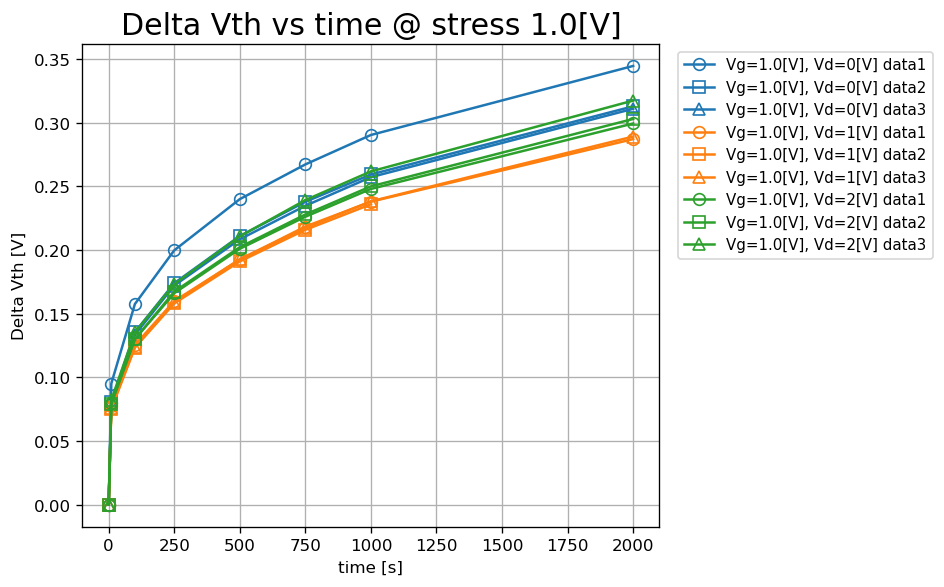

In [24]:
vd_color_map = {
    0: 'tab:blue',
    1: 'tab:orange',
    2: 'tab:green',
}

data_marker_map = {
    1: 'o',
    2: 's',
    3: '^',
}

plt.figure(figsize=(8, 5))

for result in results:
    delta_series = pd.Series(result["delta_vth_by_time"]).sort_index()
    line_color = vd_color_map.get(result["vd"], 'black')
    line_marker = data_marker_map.get(result["data_idx"], 'o')

    plt.plot(
        delta_series.index.to_numpy(),
        delta_series.to_numpy(),
        color=line_color,
        marker=line_marker,
        markerfacecolor='none',
        markersize=7,
        linewidth=1.5,
        label=result["label"],
    )

plt.xlabel('time [s]')
plt.ylabel('Delta Vth [V]')
plt.title('Delta Vth vs time @ stress 1.0[V]', fontsize=18)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()


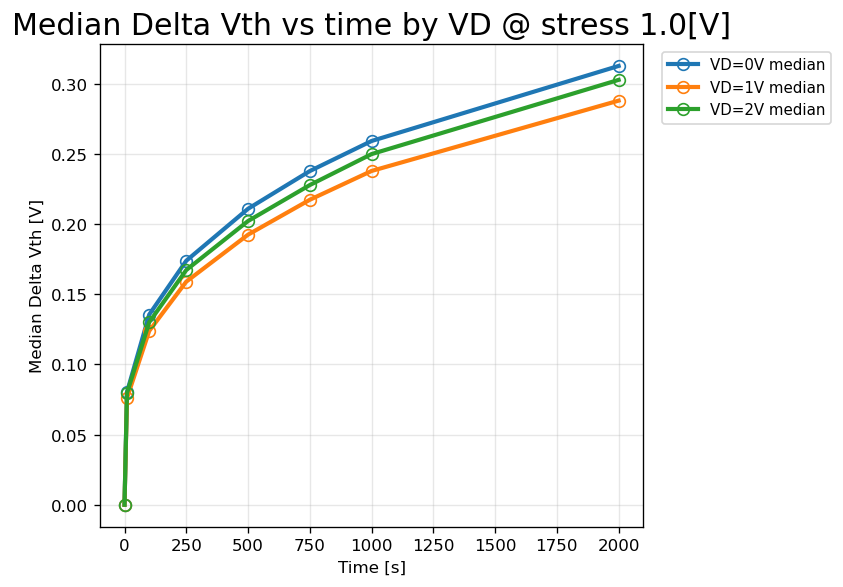

,vd,time_s,delta_vth
0,0,0,0.000000
1,0,10,0.080304
2,0,100,0.135574
3,0,250,0.173987
4,0,500,0.211033
5,0,750,0.237921
6,0,1000,0.259368
7,0,2000,0.312887
8,1,0,0.000000
9,1,10,0.075994


In [25]:
median_rows = []

for result in results:
    for time_s, delta_vth in result["delta_vth_by_time"].items():
        if pd.notna(delta_vth):
            median_rows.append({
                "vd": result["vd"],
                "time_s": time_s,
                "delta_vth": delta_vth,
            })

median_df = pd.DataFrame(median_rows)
median_df = median_df.groupby(["vd", "time_s"], as_index=False)["delta_vth"].median()

plt.figure(figsize=(7, 5))

for vd, group in median_df.groupby("vd"):
    group = group.sort_values("time_s")
    plt.plot(
        group["time_s"].to_numpy(),
        group["delta_vth"].to_numpy(),
        color=vd_color_map.get(vd, "black"),
        marker="o", markerfacecolor='none',
        linewidth=2.5,
        markersize=7,
        label=f"VD={vd}V median",
    )

plt.xlabel("Time [s]")
plt.ylabel("Median Delta Vth [V]")
plt.title("Median Delta Vth vs time by VD @ stress 1.0[V]", fontsize=18)
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

median_df


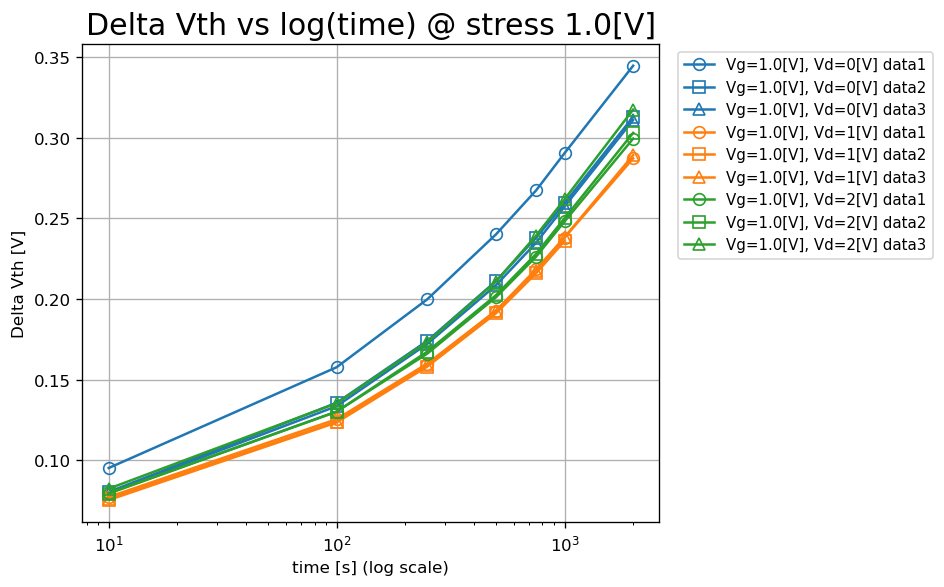

In [26]:
plt.figure(figsize=(8, 5))

for result in results:
    delta_series = pd.Series(result["delta_vth_by_time"]).sort_index()
    delta_series = delta_series[delta_series.index > 0]
    line_color = vd_color_map.get(result["vd"], 'black')
    line_marker = data_marker_map.get(result["data_idx"], 'o')

    plt.plot(
        delta_series.index.to_numpy(),
        delta_series.to_numpy(),
        color=line_color,
        marker=line_marker,
        markerfacecolor='none',
        markersize=7,
        linewidth=1.5,
        label=result["label"],
    )

plt.xscale('log')
plt.xlabel('time [s] (log scale)')
plt.ylabel('Delta Vth [V]')
plt.title('Delta Vth vs log(time) @ stress 1.0[V]', fontsize=18)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()


In [27]:
all_times = sorted({time_s for result in results for time_s in result["delta_vth_by_time"].keys()})

summary_rows = []
for result in results:
    row = {
        "legend": result["label"],
        "stress_vg[V]": result["vg"],
        "stress_vd[V]": result["vd"],
        "initial_vth[V]": result["initial_vth"],
    }

    for time_s in all_times:
        row[f"delta_vth@{int(time_s)}s[V]"] = result["delta_vth_by_time"].get(time_s, np.nan)

    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values(["stress_vd[V]", "legend"]).reset_index(drop=True)

display(summary_df.round(4))


,legend,stress_vg[V],stress_vd[V],initial_vth[V],delta_vth@0s[V],delta_vth@10s[V],delta_vth@100s[V],delta_vth@250s[V],delta_vth@500s[V],delta_vth@750s[V],delta_vth@1000s[V],delta_vth@2000s[V]
0,"Vg=1.0[V], Vd=0[V] data1",1.0,0,0.2371,0.0,0.0952,0.1576,0.1998,0.2400,0.2673,0.2904,0.3446
1,"Vg=1.0[V], Vd=0[V] data2",1.0,0,0.2772,0.0,0.0803,0.1356,0.1740,0.2110,0.2379,0.2594,0.3129
2,"Vg=1.0[V], Vd=0[V] data3",1.0,0,0.2656,0.0,0.0799,0.1335,0.1721,0.2085,0.2348,0.2573,0.3110
3,"Vg=1.0[V], Vd=1[V] data1",1.0,1,0.2648,0.0,0.0772,0.1254,0.1599,0.1926,0.2185,0.2380,0.2871
4,"Vg=1.0[V], Vd=1[V] data2",1.0,1,0.2682,0.0,0.0753,0.1234,0.1581,0.1911,0.2159,0.2359,NaN
5,"Vg=1.0[V], Vd=1[V] data3",1.0,1,0.2774,0.0,0.0760,0.1239,0.1591,0.1928,0.2175,0.2383,0.2891
6,"Vg=1.0[V], Vd=2[V] data1",1.0,2,0.2782,0.0,0.0796,0.1301,0.1661,0.2010,0.2262,0.2480,0.2994
7,"Vg=1.0[V], Vd=2[V] data2",1.0,2,0.2657,0.0,0.0793,0.1301,0.1674,0.2023,0.2279,0.2500,0.3030
8,"Vg=1.0[V], Vd=2[V] data3",1.0,2,0.2452,0.0,0.0823,0.1353,0.1733,0.2107,0.2393,0.2618,0.3174


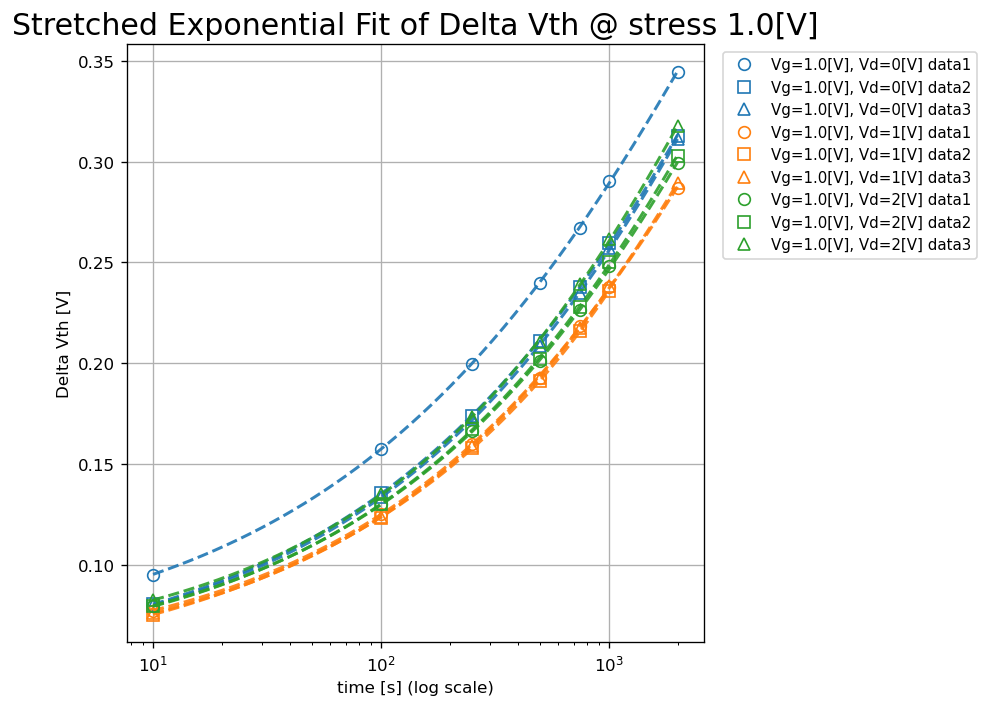

,legend,stress_vg[V],stress_vd[V],data_idx,V_pre[V],tau[s],beta,V_inf[V],fit_rmse[V]
0,"Vg=1.0[V], Vd=0[V] data1",1.0,0,1,0.5705,4.430355e+03,0.4241,0.6243,0.0006
1,"Vg=1.0[V], Vd=0[V] data2",1.0,0,2,0.5844,6.197418e+03,0.4352,0.6302,0.0005
2,"Vg=1.0[V], Vd=0[V] data3",1.0,0,3,0.6013,6.940098e+03,0.4389,0.6481,0.0007
3,"Vg=1.0[V], Vd=1[V] data1",1.0,1,1,0.5081,5.475593e+03,0.4573,0.5578,0.0008
4,"Vg=1.0[V], Vd=1[V] data2",1.0,1,2,59.3737,5.978518e+09,0.3657,59.4124,0.0004
5,"Vg=1.0[V], Vd=1[V] data3",1.0,1,3,0.5581,7.025708e+03,0.4529,0.6062,0.0006
6,"Vg=1.0[V], Vd=2[V] data1",1.0,2,1,0.5708,6.867826e+03,0.4467,0.6205,0.0008
7,"Vg=1.0[V], Vd=2[V] data2",1.0,2,2,0.6109,8.077511e+03,0.4425,0.6595,0.0007
8,"Vg=1.0[V], Vd=2[V] data3",1.0,2,3,0.5566,5.108906e+03,0.4702,0.6103,0.0008


In [28]:
def stretched_exponential(t, v_pre, tau, beta, v_inf):
    return -v_pre * np.exp(-((t / tau) ** beta)) + v_inf


fit_rows = []

plt.figure(figsize=(8, 6))

for result in results:
    delta_series = pd.Series(result["delta_vth_by_time"]).sort_index()
    delta_series = delta_series[(delta_series.index > 0) & (~delta_series.isna())]

    line_color = vd_color_map.get(result["vd"], 'black')
    line_marker = data_marker_map.get(result["data_idx"], 'o')

    fit_row = {
        "legend": result["label"],
        "stress_vg[V]": result["vg"],
        "stress_vd[V]": result["vd"],
        "data_idx": result["data_idx"],
        "V_pre[V]": np.nan,
        "tau[s]": np.nan,
        "beta": np.nan,
        "V_inf[V]": np.nan,
        "fit_rmse[V]": np.nan,
    }

    if len(delta_series) >= 4:
        x_data = delta_series.index.to_numpy(dtype=float)
        y_data = delta_series.to_numpy(dtype=float)

        v_inf_guess = float(np.nanmax(y_data))
        v_pre_guess = float(max(v_inf_guess - y_data[0], 1e-6))
        tau_guess = float(np.median(x_data))
        beta_guess = 0.5

        lower_bounds = [0.0, 1e-12, 0.0, -np.inf]
        upper_bounds = [np.inf, np.inf, 2.0, np.inf]

        try:
            popt, _ = curve_fit(
                stretched_exponential,
                x_data,
                y_data,
                p0=[v_pre_guess, tau_guess, beta_guess, v_inf_guess],
                bounds=(lower_bounds, upper_bounds),
                maxfev=20000,
            )

            y_fit = stretched_exponential(x_data, *popt)
            rmse = float(np.sqrt(np.mean((y_data - y_fit) ** 2)))

            fit_row["V_pre[V]"] = popt[0]
            fit_row["tau[s]"] = popt[1]
            fit_row["beta"] = popt[2]
            fit_row["V_inf[V]"] = popt[3]
            fit_row["fit_rmse[V]"] = rmse

            x_fit = np.logspace(np.log10(x_data.min()), np.log10(x_data.max()), 300)
            y_fit_dense = stretched_exponential(x_fit, *popt)

            plt.plot(
                x_fit,
                y_fit_dense,
                color=line_color,
                linestyle='--',
                linewidth=1.8,
                alpha=0.9,
            )
        except RuntimeError:
            pass

    plt.plot(
        delta_series.index.to_numpy(),
        delta_series.to_numpy(),
        linestyle='None',
        color=line_color,
        marker=line_marker,
        markerfacecolor='none',
        markersize=7,
        label=result["label"],
    )

    fit_rows.append(fit_row)

plt.xscale('log')
plt.xlabel('time [s] (log scale)')
plt.ylabel('Delta Vth [V]')
plt.title('Stretched Exponential Fit of Delta Vth @ stress 1.0[V]', fontsize=18)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

fit_df = pd.DataFrame(fit_rows)
fit_df = fit_df.sort_values(["stress_vd[V]", "data_idx"]).reset_index(drop=True)
display(fit_df.round(4))


In [29]:
all_ss_times = sorted({time_s for result in results for time_s in result["ss_by_time"].keys()})

ss_rows = []
for result in results:
    row = {
        "legend": result["label"],
        "stress_vg[V]": result["vg"],
        "stress_vd[V]": result["vd"],
    }

    for time_s in all_ss_times:
        row[f"ss@{int(time_s)}s[mV/dec]"] = result["ss_by_time"].get(time_s, np.nan)

    ss_rows.append(row)

ss_df = pd.DataFrame(ss_rows)
ss_df = ss_df.sort_values(["stress_vd[V]", "legend"]).reset_index(drop=True)
display(ss_df.round(4))


,legend,stress_vg[V],stress_vd[V],ss@0s[mV/dec],ss@10s[mV/dec],ss@100s[mV/dec],ss@250s[mV/dec],ss@500s[mV/dec],ss@750s[mV/dec],ss@1000s[mV/dec],ss@2000s[mV/dec]
0,"Vg=1.0[V], Vd=0[V] data1",1.0,0,135.6606,133.7393,136.9459,137.5211,137.3501,136.9600,136.9413,136.2462
1,"Vg=1.0[V], Vd=0[V] data2",1.0,0,130.4772,131.1459,133.5059,136.0747,136.2432,135.0240,136.0029,135.2285
2,"Vg=1.0[V], Vd=0[V] data3",1.0,0,129.4938,131.2083,134.9148,135.8458,135.9395,137.1210,135.8261,135.4391
3,"Vg=1.0[V], Vd=1[V] data1",1.0,1,129.4255,130.0006,132.5560,132.7115,133.3914,133.1450,133.3910,132.1953
4,"Vg=1.0[V], Vd=1[V] data2",1.0,1,129.0158,130.2468,132.7314,132.8792,132.7221,133.3298,133.4017,NaN
5,"Vg=1.0[V], Vd=1[V] data3",1.0,1,129.1455,129.9514,132.7161,132.9652,132.1600,133.3908,131.6230,130.0252
6,"Vg=1.0[V], Vd=2[V] data1",1.0,2,128.7993,128.5959,130.6708,132.1634,131.3556,131.9628,130.2742,128.4925
7,"Vg=1.0[V], Vd=2[V] data2",1.0,2,127.6521,128.7290,131.3585,131.5306,130.7014,131.8897,130.0733,128.2785
8,"Vg=1.0[V], Vd=2[V] data3",1.0,2,130.2582,127.9190,130.8825,130.9530,132.5515,131.3857,131.2286,128.2571


In [30]:
all_mu_times = sorted({time_s for result in results for time_s in result["mobility_by_time"].keys()})

mu_rows = []
for result in results:
    vd_values_used = [v for v in result["vd_used_by_time"].values() if not np.isnan(v)]
    row = {
        "legend": result["label"],
        "stress_vg[V]": result["vg"],
        "stress_vd[V]": result["vd"],
        "Cox_total[pF]": Cox_total_F * 1e12,
        "mu_calc_vd[V]": vd_values_used[0] if len(vd_values_used) > 0 else np.nan,
    }

    for time_s in all_mu_times:
        row[f"mu@{int(time_s)}s[cm^2/Vs]"] = result["mobility_by_time"].get(time_s, np.nan)

    mu_rows.append(row)

mu_df = pd.DataFrame(mu_rows)
mu_df = mu_df.sort_values(["stress_vd[V]", "legend"]).reset_index(drop=True)
display(mu_df.round(4))


,legend,stress_vg[V],stress_vd[V],Cox_total[pF],mu_calc_vd[V],mu@0s[cm^2/Vs],mu@10s[cm^2/Vs],mu@100s[cm^2/Vs],mu@250s[cm^2/Vs],mu@500s[cm^2/Vs],mu@750s[cm^2/Vs],mu@1000s[cm^2/Vs],mu@2000s[cm^2/Vs]
0,"Vg=1.0[V], Vd=0[V] data1",1.0,0,4.25,0.1,9.5831,9.8428,9.8673,9.8654,9.8146,9.8108,9.7864,9.6885
1,"Vg=1.0[V], Vd=0[V] data2",1.0,0,4.25,0.1,9.3713,9.5981,9.6527,9.6678,9.6565,9.6809,9.6602,9.6094
2,"Vg=1.0[V], Vd=0[V] data3",1.0,0,4.25,0.1,9.5624,9.8184,9.8579,9.8447,9.8202,9.7976,9.7619,9.6791
3,"Vg=1.0[V], Vd=1[V] data1",1.0,1,4.25,0.1,9.5849,9.8419,9.8786,9.8635,9.8635,9.8466,9.8184,9.7449
4,"Vg=1.0[V], Vd=1[V] data2",1.0,1,4.25,0.1,9.5624,9.8071,9.8456,9.8447,9.8315,9.8108,9.7864,0.0001
5,"Vg=1.0[V], Vd=1[V] data3",1.0,1,4.25,0.1,9.5671,9.8052,9.8485,9.8654,9.8259,9.8184,9.7939,9.7224
6,"Vg=1.0[V], Vd=2[V] data1",1.0,2,4.25,0.1,9.5887,9.8259,9.8673,9.8494,9.8419,9.8278,9.7995,9.7336
7,"Vg=1.0[V], Vd=2[V] data2",1.0,2,4.25,0.1,9.6301,9.8673,9.9012,9.9106,9.8776,9.8635,9.8579,9.7788
8,"Vg=1.0[V], Vd=2[V] data3",1.0,2,4.25,0.1,9.6546,9.8880,9.9275,9.9219,9.9162,9.9012,9.8711,9.8071
